In [13]:
!pip install hmmlearn

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from scipy.special import logsumexp

OUTPUT_DIR = Path("outputs/hmm")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

## Load modelling dataframe

In [15]:
from pathlib import Path
import pandas as pd

model_path = Path("outputs/model_df.parquet")

if not model_path.exists():
    raise FileNotFoundError(
        "outputs/model_df.parquet was not found. "
        "Please run the saving cell in preprocessing_baseline_models.ipynb first."
    )

model_df = pd.read_parquet(model_path)

model_df["Date"] = pd.to_datetime(model_df["Date"])
model_df["Target_Date"] = pd.to_datetime(model_df["Target_Date"])

model_df = model_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

tickers = sorted(model_df["Ticker"].unique())

print("Loaded model_df:", model_df.shape)
print("Tickers:", tickers)

display(model_df.head())

Loaded model_df: (11889, 33)
Tickers: ['AAPL', 'IBM', 'MSFT']


,Date,Open,High,Low,Close,Volume,Ticker,Log_Close,Log_Return,Simple_Return,...,Momentum_10,MA_Gap_10,Rolling_Vol_20,Momentum_20,MA_Gap_20,Rolling_Vol_60,Momentum_60,MA_Gap_60,Drawdown_20,Split
0,2010-03-31,7.049493,7.083020,7.018659,7.034823,430659600,AAPL,1.950873,-0.003611,-0.003605,...,0.047403,0.026124,0.011924,0.115673,0.041833,0.017348,0.093563,0.114787,-0.003605,train
1,2010-04-01,7.106970,7.146485,6.967471,7.063863,603145200,AAPL,1.954992,0.004120,0.004128,...,0.049161,0.025292,0.011928,0.113222,0.040308,0.017351,0.095955,0.117482,0.000000,train
2,2010-04-05,7.034229,7.139901,7.027942,7.139302,684507600,AAPL,1.965615,0.010623,0.010680,...,0.070525,0.028981,0.009235,0.085484,0.046909,0.017233,0.122612,0.126968,0.000000,train
3,2010-04-06,7.130617,7.191686,7.094695,7.170731,447017200,AAPL,1.970008,0.004393,0.004402,...,0.063731,0.026958,0.009194,0.089284,0.046817,0.017228,0.128855,0.129353,0.000000,train
4,2010-04-07,7.171031,7.241978,7.144388,7.202464,628502000,AAPL,1.974423,0.004416,0.004425,...,0.052212,0.026118,0.008641,0.075874,0.047426,0.017221,0.126644,0.131806,0.000000,train


## Sanity checks

In [16]:
required_cols = [
    "Ticker",
    "Date",
    "Target_Date",
    "Split",
    "Log_Return",
    "Rolling_Vol_20",
    "Next_Day_Log_Return",
]

missing_cols = [col for col in required_cols if col not in model_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

display(model_df[required_cols].head())

display(
    model_df.groupby(["Ticker", "Split"])
    .size()
    .unstack(fill_value=0)
)

display(
    model_df[["Log_Return", "Rolling_Vol_20", "Next_Day_Log_Return"]]
    .describe()
)

display(
    model_df[required_cols].isna().sum()
)

,Ticker,Date,Target_Date,Split,Log_Return,Rolling_Vol_20,Next_Day_Log_Return
0,AAPL,2010-03-31,2010-04-01,train,-0.003611,0.011924,0.004120
1,AAPL,2010-04-01,2010-04-05,train,0.004120,0.011928,0.010623
2,AAPL,2010-04-05,2010-04-06,train,0.010623,0.009235,0.004393
3,AAPL,2010-04-06,2010-04-07,train,0.004393,0.009194,0.004416
4,AAPL,2010-04-07,2010-04-08,train,0.004416,0.008641,-0.002705


Split,test,train,validation
Ticker,,,
AAPL,752,2708,503
IBM,752,2708,503
MSFT,752,2708,503


,Log_Return,Rolling_Vol_20,Next_Day_Log_Return
count,11889.000000,11889.000000,11889.000000
mean,0.000688,0.014635,0.000687
std,0.016153,0.006984,0.016154
min,-0.159453,0.003491,-0.159453
25%,-0.006817,0.010056,-0.006825
50%,0.000743,0.013302,0.000743
75%,0.008688,0.017422,0.008688
max,0.142617,0.071463,0.142617


Ticker                 0
Date                   0
Target_Date            0
Split                  0
Log_Return             0
Rolling_Vol_20         0
Next_Day_Log_Return    0
dtype: int64

## Fit per-ticker 2-state Gaussian HMMs

In [17]:
HMM_FEATURE_COLS = ["Log_Return", "Rolling_Vol_20"]
N_STATES = 2
RANDOM_STATE = 5
MIN_TRAIN_OBS = 100


def filtered_state_probabilities(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """Return causal filtered P(state_t | observations through t) for a fitted HMM."""
    if X.ndim != 2:
        raise ValueError("X must be a 2D array.")

    log_likelihood = model._compute_log_likelihood(X)
    tiny = np.finfo(float).tiny
    log_startprob = np.log(np.clip(model.startprob_, tiny, 1.0))
    log_transmat = np.log(np.clip(model.transmat_, tiny, 1.0))

    log_alpha = np.empty_like(log_likelihood)
    log_alpha[0] = log_startprob + log_likelihood[0]
    log_alpha[0] -= logsumexp(log_alpha[0])

    for t in range(1, len(X)):
        log_alpha[t] = log_likelihood[t] + logsumexp(
            log_alpha[t - 1][:, None] + log_transmat,
            axis=0,
        )
        log_alpha[t] -= logsumexp(log_alpha[t])

    return np.exp(log_alpha)


In [18]:
hmm_frames = []
state_summary_rows = []
transition_frames = []
duration_rows = []
model_selection_rows = []

for ticker in tickers:
    ticker_df = model_df.loc[model_df["Ticker"] == ticker].copy()
    train_df = ticker_df.loc[ticker_df["Split"] == "train"].dropna(subset=HMM_FEATURE_COLS).copy()

    if len(train_df) < MIN_TRAIN_OBS:
        raise ValueError(f"{ticker}: not enough training observations for HMM fitting.")

    if ticker_df[HMM_FEATURE_COLS].isna().any().any():
        missing_counts = ticker_df[HMM_FEATURE_COLS].isna().sum().to_dict()
        raise ValueError(f"{ticker}: HMM feature columns contain missing values: {missing_counts}")

    scaler = StandardScaler()
    train_X = scaler.fit_transform(train_df[HMM_FEATURE_COLS])
    all_X = scaler.transform(ticker_df[HMM_FEATURE_COLS])

    hmm = GaussianHMM(
        n_components=N_STATES,
        covariance_type="full",
        n_iter=1000,
        tol=1e-4,
        random_state=RANDOM_STATE,
        verbose=False,
    )
    hmm.fit(train_X)

    train_probs = filtered_state_probabilities(hmm, train_X)
    train_states = train_probs.argmax(axis=1)
    train_labeled = train_df.assign(HMM_State=train_states)

    state_return_means = train_labeled.groupby("HMM_State")["Log_Return"].mean()
    if len(state_return_means) < N_STATES:
        fallback_means = pd.Series(
            scaler.inverse_transform(hmm.means_)[:, HMM_FEATURE_COLS.index("Log_Return")],
            index=range(N_STATES),
        )
        state_return_means = state_return_means.reindex(range(N_STATES)).fillna(fallback_means)

    bullish_state = int(state_return_means.idxmax())
    bearish_state = int([state for state in range(N_STATES) if state != bullish_state][0])
    label_map = {bullish_state: "Bullish", bearish_state: "Bearish"}

    filtered_probs = filtered_state_probabilities(hmm, all_X)
    next_probs = filtered_probs @ hmm.transmat_
    filtered_states = filtered_probs.argmax(axis=1)

    ticker_out = ticker_df.copy()
    ticker_out["HMM_State"] = filtered_states
    ticker_out["HMM_Regime_Label"] = ticker_out["HMM_State"].map(label_map)
    ticker_out["HMM_Regime"] = ticker_out["HMM_Regime_Label"]

    for state in range(N_STATES):
        ticker_out[f"HMM_Prob_State_{state}"] = filtered_probs[:, state]
        ticker_out[f"HMM_Prob_State_{state}_Next"] = next_probs[:, state]

    ticker_out["HMM_Bullish_Prob"] = filtered_probs[:, bullish_state]
    ticker_out["HMM_Bearish_Prob"] = filtered_probs[:, bearish_state]
    ticker_out["HMM_Bullish_Prob_Next"] = next_probs[:, bullish_state]
    ticker_out["HMM_Bearish_Prob_Next"] = next_probs[:, bearish_state]
    ticker_out["HMM_Bullish_State"] = bullish_state
    ticker_out["HMM_Bearish_State"] = bearish_state
    ticker_out["HMM_Features"] = ", ".join(HMM_FEATURE_COLS)
    hmm_frames.append(ticker_out)

    transition_matrix = pd.DataFrame(
        hmm.transmat_,
        columns=[f"to_state_{i}" for i in range(hmm.n_components)],
        index=[f"from_state_{i}" for i in range(hmm.n_components)],
    )
    transition_matrix = (
        transition_matrix
        .reset_index()
        .rename(columns={"index": "from_state"})
    )
    transition_matrix["Ticker"] = ticker
    transition_frames.append(
        transition_matrix[["Ticker", "from_state"] + [f"to_state_{i}" for i in range(hmm.n_components)]]
    )

    for state in range(N_STATES):
        stay_probability = float(hmm.transmat_[state, state])
        expected_duration = (
            np.inf
            if np.isclose(1.0 - stay_probability, 0.0)
            else 1.0 / (1.0 - stay_probability)
        )
        duration_rows.append(
            {
                "Ticker": ticker,
                "HMM_State": state,
                "stay_probability": stay_probability,
                "expected_duration_days": float(expected_duration),
            }
        )

    for state in range(N_STATES):
        full_state_mask = ticker_out["HMM_State"] == state
        state_summary_rows.append(
            {
                "Ticker": ticker,
                "HMM_State": state,
                "Regime_Label": label_map[state],
                "mean_return": ticker_out.loc[full_state_mask, "Log_Return"].mean(),
                "realized_volatility": ticker_out.loc[full_state_mask, "Log_Return"].std(ddof=0),
                "mean_rolling_vol20": ticker_out.loc[full_state_mask, "Rolling_Vol_20"].mean(),
                "count": int(full_state_mask.sum()),
            }
        )

    model_selection_rows.append(
        {
            "Ticker": ticker,
            "Train_Rows": int(len(train_df)),
            "All_Rows": int(len(ticker_df)),
            "Converged": bool(hmm.monitor_.converged),
            "Iterations": int(hmm.monitor_.iter),
            "Train_Log_Likelihood": float(hmm.score(train_X)),
            "Bullish_State": bullish_state,
            "Bearish_State": bearish_state,
            "Start_Prob_State_0": float(hmm.startprob_[0]),
            "Start_Prob_State_1": float(hmm.startprob_[1]),
            "Transition_00": float(hmm.transmat_[0, 0]),
            "Transition_01": float(hmm.transmat_[0, 1]),
            "Transition_10": float(hmm.transmat_[1, 0]),
            "Transition_11": float(hmm.transmat_[1, 1]),
        }
    )

hmm_regime_df = pd.concat(hmm_frames, ignore_index=True)
hmm_state_summary_df = pd.DataFrame(state_summary_rows)
hmm_duration_df = pd.DataFrame(duration_rows)
hmm_transition_df = pd.concat(transition_frames, ignore_index=True)
hmm_model_selection_df = pd.DataFrame(model_selection_rows)

hmm_state_summary_df = hmm_state_summary_df.merge(
    hmm_duration_df,
    on=["Ticker", "HMM_State"],
    how="left",
)

required_hmm_feature_cols = [
    "Ticker",
    "Date",
    "Target_Date",
    "Split",
    "Log_Return",
    "Rolling_Vol_20",
    "Next_Day_Log_Return",
    "HMM_State",
    "HMM_Regime_Label",
    "HMM_Bullish_Prob",
    "HMM_Bearish_Prob",
    "HMM_Bullish_Prob_Next",
    "HMM_Bearish_Prob_Next",
]

missing_hmm_feature_cols = [
    col for col in required_hmm_feature_cols
    if col not in hmm_regime_df.columns
]
if missing_hmm_feature_cols:
    raise ValueError(f"Missing HMM feature columns: {missing_hmm_feature_cols}")

state_summary_df = hmm_state_summary_df
diagnostics_df = hmm_model_selection_df

print("HMM regime dataframe:", hmm_regime_df.shape)
print("HMM state summary dataframe:", hmm_state_summary_df.shape)
print("HMM transition dataframe:", hmm_transition_df.shape)


HMM regime dataframe: (11889, 47)
HMM state summary dataframe: (6, 9)
HMM transition dataframe: (6, 4)


## Inspect inferred regimes

In [19]:
display(hmm_model_selection_df)

display(
    hmm_transition_df.sort_values(["Ticker", "from_state"])
)

display(
    hmm_state_summary_df.sort_values(["Ticker", "Regime_Label"])
)

display(
    hmm_regime_df.groupby(["Ticker", "Split", "HMM_Regime_Label"])
    .size()
    .unstack(fill_value=0)
)

display(
    hmm_regime_df[required_hmm_feature_cols].head()
)


,Ticker,Train_Rows,All_Rows,Converged,Iterations,Train_Log_Likelihood,Bullish_State,Bearish_State,Start_Prob_State_0,Start_Prob_State_1,Transition_00,Transition_01,Transition_10,Transition_11
0,AAPL,2708,3963,True,24,-5876.371656,1,0,1.098452e-44,1.000000e+00,0.970956,0.029044,0.013974,0.986026
1,IBM,2708,3963,True,30,-5633.882750,1,0,1.031634e-58,1.000000e+00,0.967459,0.032541,0.020160,0.979840
2,MSFT,2708,3963,True,22,-5703.330696,1,0,1.000000e+00,1.318085e-31,0.986254,0.013746,0.034951,0.965049


,Ticker,from_state,to_state_0,to_state_1
0,AAPL,from_state_0,0.970956,0.029044
1,AAPL,from_state_1,0.013974,0.986026
2,IBM,from_state_0,0.967459,0.032541
3,IBM,from_state_1,0.020160,0.979840
4,MSFT,from_state_0,0.986254,0.013746
5,MSFT,from_state_1,0.034951,0.965049


,Ticker,HMM_State,Regime_Label,mean_return,realized_volatility,mean_rolling_vol20,count,stay_probability,expected_duration_days
0,AAPL,0,Bearish,0.000589,0.024843,0.023647,1323,0.970956,34.430137
1,AAPL,1,Bullish,0.001089,0.012778,0.012518,2640,0.986026,71.561688
2,IBM,0,Bearish,0.000314,0.019407,0.018120,1718,0.967459,30.730280
3,IBM,1,Bullish,0.000404,0.008913,0.009014,2245,0.979840,49.604184
4,MSFT,0,Bearish,0.000856,0.011581,0.011345,2699,0.986254,72.749490
5,MSFT,1,Bullish,0.000612,0.022955,0.021899,1264,0.965049,28.611448


HMM_Regime_Label   Bearish  Bullish
Ticker Split                       
AAPL   test            161      591
       train           892     1816
       validation      270      233
IBM    test            387      365
       train          1065     1643
       validation      266      237
MSFT   test            551      201
       train          1919      789
       validation      229      274

,Ticker,Date,Target_Date,Split,Log_Return,Rolling_Vol_20,Next_Day_Log_Return,HMM_State,HMM_Regime_Label,HMM_Bullish_Prob,HMM_Bearish_Prob,HMM_Bullish_Prob_Next,HMM_Bearish_Prob_Next
0,AAPL,2010-03-31,2010-04-01,train,-0.003611,0.011924,0.004120,1,Bullish,1.000000,7.052034e-46,0.986026,0.013974
1,AAPL,2010-04-01,2010-04-05,train,0.004120,0.011928,0.010623,1,Bullish,0.999148,8.524932e-04,0.985210,0.014790
2,AAPL,2010-04-05,2010-04-06,train,0.010623,0.009235,0.004393,1,Bullish,0.998873,1.127500e-03,0.984947,0.015053
3,AAPL,2010-04-06,2010-04-07,train,0.004393,0.009194,0.004416,1,Bullish,0.999041,9.586893e-04,0.985109,0.014891
4,AAPL,2010-04-07,2010-04-08,train,0.004416,0.008641,-0.002705,1,Bullish,0.998953,1.046836e-03,0.985024,0.014976


## Plot HMM regimes

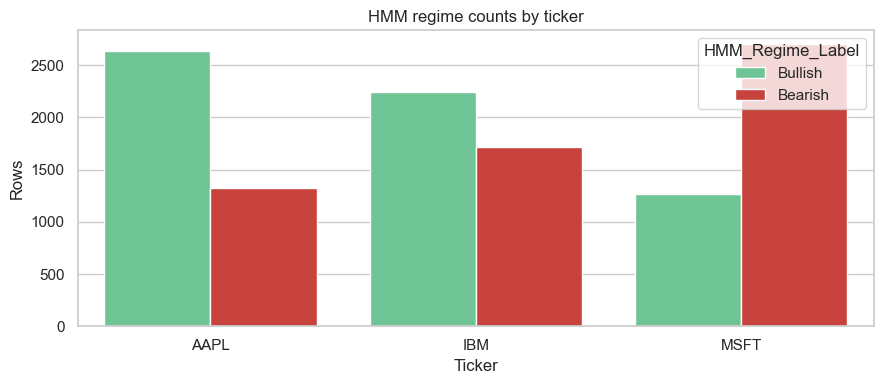

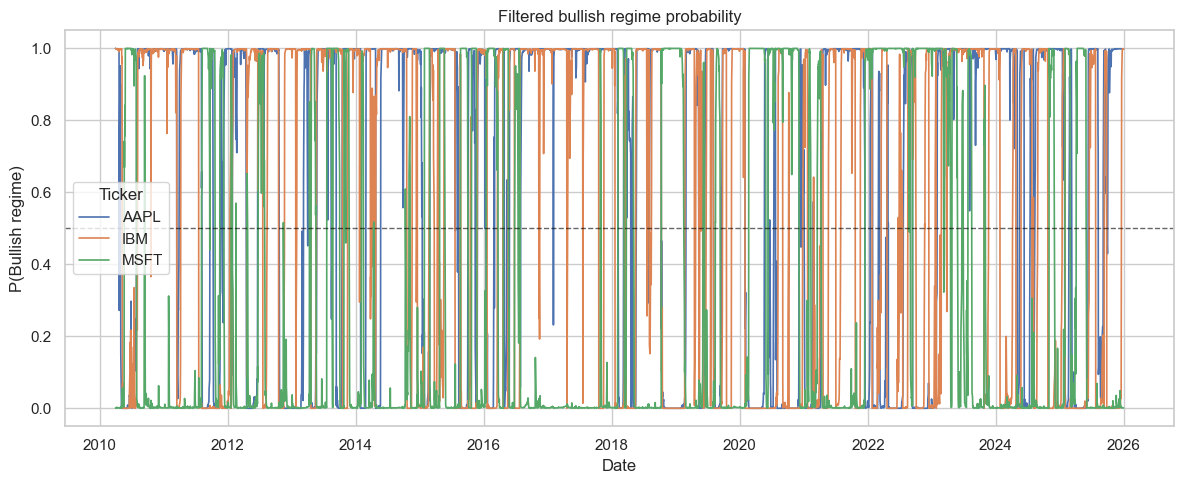

In [20]:
regime_palette = {"Bullish": "#60d292", "Bearish": "#de2d26"}

fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(
    data=hmm_regime_df,
    x="Ticker",
    hue="HMM_Regime_Label",
    palette=regime_palette,
    ax=ax,
)
ax.set_title("HMM regime counts by ticker")
ax.set_xlabel("Ticker")
ax.set_ylabel("Rows")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "hmm_regime_counts.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for ticker in tickers:
    ticker_plot = hmm_regime_df.loc[hmm_regime_df["Ticker"] == ticker]
    ax.plot(ticker_plot["Date"], ticker_plot["HMM_Bullish_Prob"], label=ticker, linewidth=1.2)

ax.axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.set_title("Filtered bullish regime probability")
ax.set_xlabel("Date")
ax.set_ylabel("P(Bullish regime)")
ax.legend(title="Ticker")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "hmm_bullish_probabilities.png", dpi=150, bbox_inches="tight")
plt.show()


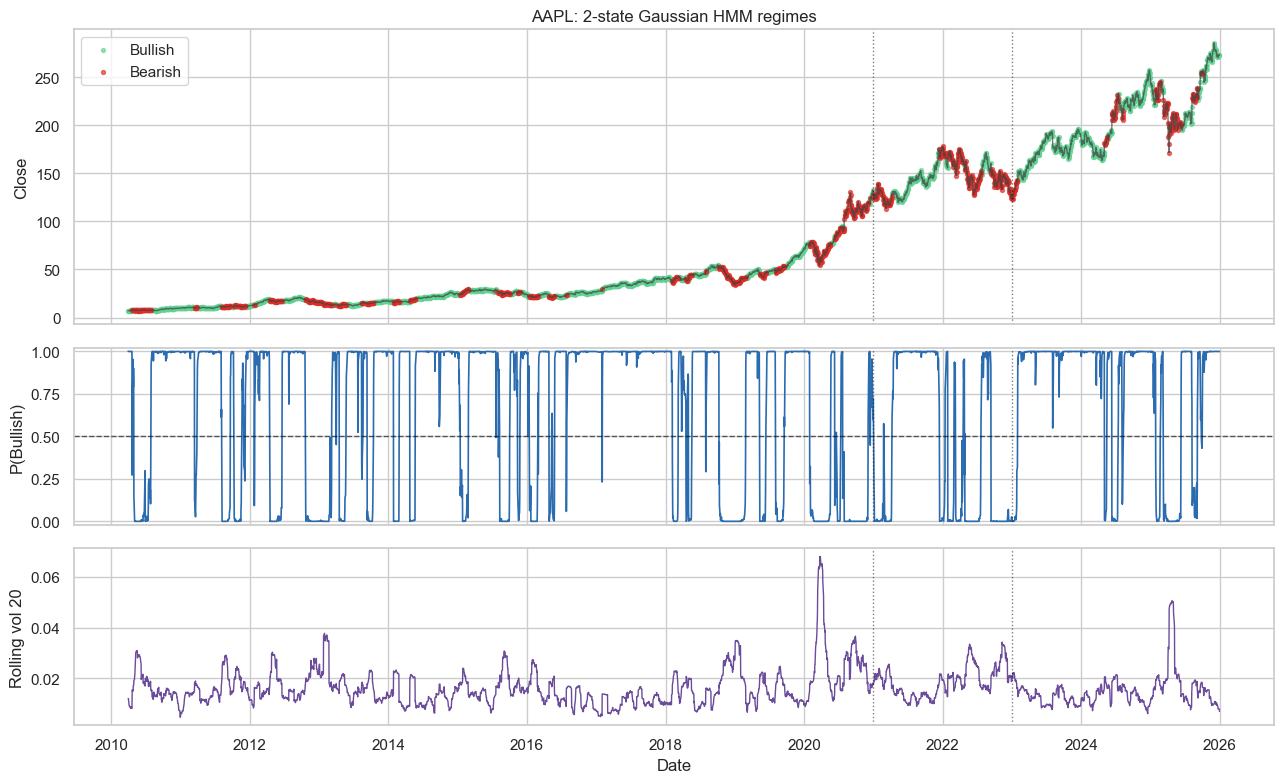

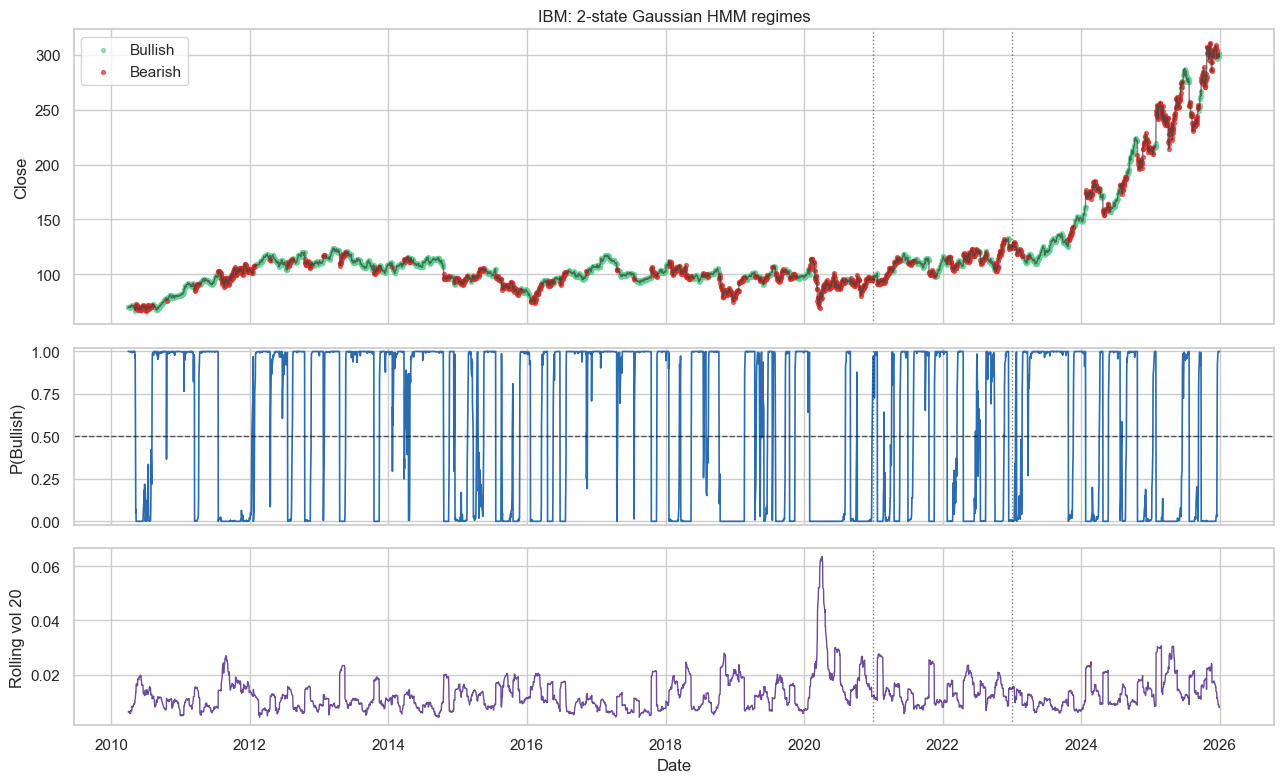

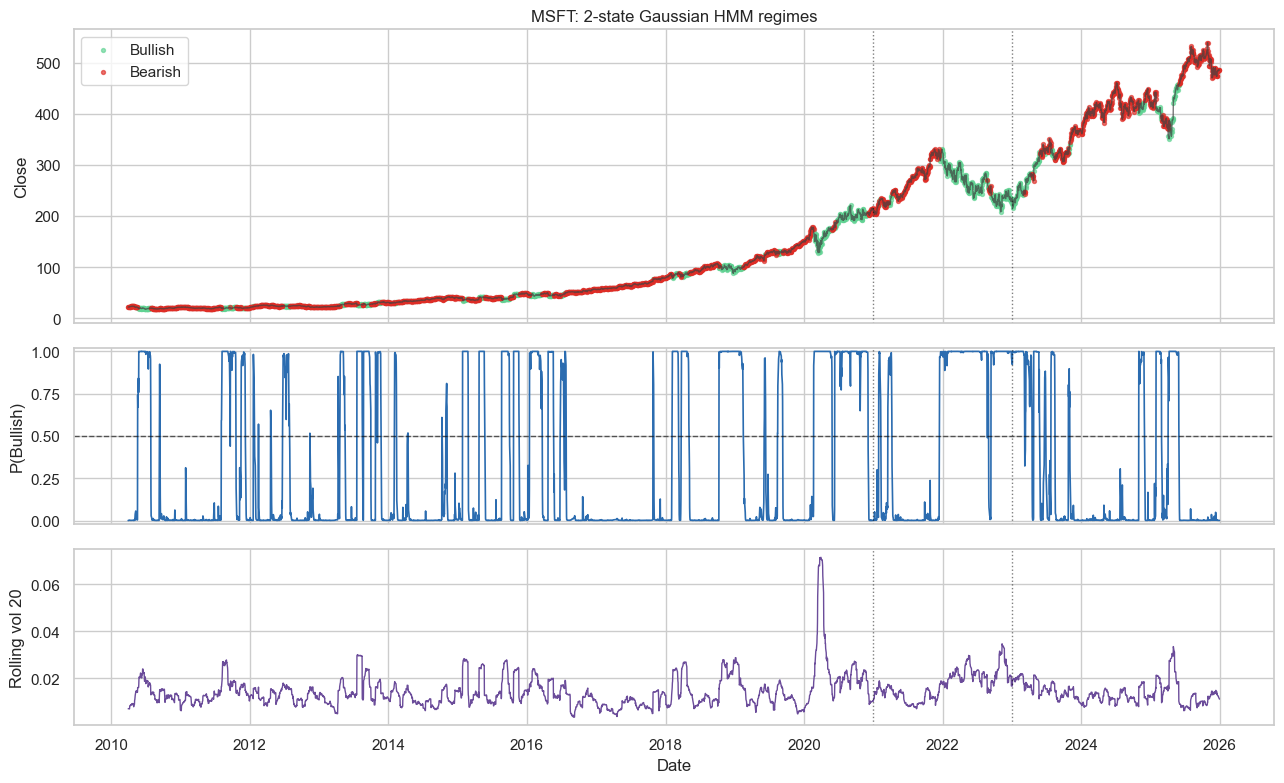

In [21]:
for ticker in tickers:
    ticker_plot = hmm_regime_df.loc[hmm_regime_df["Ticker"] == ticker].copy()
    price_col = "Close" if "Close" in ticker_plot.columns else "Log_Return"

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(13, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [2.0, 1.2, 1.2]},
    )

    axes[0].plot(ticker_plot["Date"], ticker_plot[price_col], color="0.25", linewidth=1, alpha=0.7)
    for regime, color in regime_palette.items():
        subset = ticker_plot.loc[ticker_plot["HMM_Regime_Label"] == regime]
        axes[0].scatter(subset["Date"], subset[price_col], s=8, color=color, alpha=0.65, label=regime)
    axes[0].set_title(f"{ticker}: 2-state Gaussian HMM regimes")
    axes[0].set_ylabel(price_col)
    axes[0].legend(loc="best")

    axes[1].plot(ticker_plot["Date"], ticker_plot["HMM_Bullish_Prob"], color="#2b6cb0", linewidth=1.2)
    axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.6)
    axes[1].set_ylabel("P(Bullish)")
    axes[1].set_ylim(-0.02, 1.02)

    axes[2].plot(ticker_plot["Date"], ticker_plot["Rolling_Vol_20"], color="#6b4c9a", linewidth=1.0)
    axes[2].set_ylabel("Rolling vol 20")
    axes[2].set_xlabel("Date")

    for split_name in ["validation", "test"]:
        split_start = ticker_plot.loc[ticker_plot["Split"] == split_name, "Date"].min()
        if pd.notna(split_start):
            for ax in axes:
                ax.axvline(split_start, color="black", linestyle=":", linewidth=1, alpha=0.5)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{ticker}_hmm_regimes.png", dpi=150, bbox_inches="tight")
    plt.show()


## Save HMM outputs

In [22]:
OUTPUT_DIR = Path("outputs/hmm")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

regime_output_path = OUTPUT_DIR / "hmm_regime_features.parquet"
state_summary_path = OUTPUT_DIR / "hmm_state_summary.csv"
transition_path = OUTPUT_DIR / "hmm_transition_matrices.csv"
model_selection_path = OUTPUT_DIR / "hmm_model_selection.csv"

hmm_regime_df.to_parquet(
    regime_output_path,
    index=False,
)

hmm_state_summary_df.to_csv(
    state_summary_path,
    index=False,
)

hmm_transition_df.to_csv(
    transition_path,
    index=False,
)

hmm_model_selection_df.to_csv(
    model_selection_path,
    index=False,
)

print("Saved HMM regime features to:", regime_output_path)
print("Saved HMM state summary to:", state_summary_path)
print("Saved HMM transition matrices to:", transition_path)
print("Saved HMM model selection diagnostics to:", model_selection_path)
print("Saved plots to:", OUTPUT_DIR)


Saved HMM regime features to: outputs\hmm\hmm_regime_features.parquet
Saved HMM state summary to: outputs\hmm\hmm_state_summary.csv
Saved HMM transition matrices to: outputs\hmm\hmm_transition_matrices.csv
Saved HMM model selection diagnostics to: outputs\hmm\hmm_model_selection.csv
Saved plots to: outputs\hmm


In [23]:
saved_hmm_df = pd.read_parquet(OUTPUT_DIR / "hmm_regime_features.parquet")

required_saved_cols = [
    "Ticker",
    "Date",
    "Target_Date",
    "Split",
    "Log_Return",
    "Rolling_Vol_20",
    "Next_Day_Log_Return",
    "HMM_State",
    "HMM_Regime_Label",
    "HMM_Bullish_Prob",
    "HMM_Bearish_Prob",
    "HMM_Bullish_Prob_Next",
    "HMM_Bearish_Prob_Next",
]

missing_saved_cols = [
    col for col in required_saved_cols
    if col not in saved_hmm_df.columns
]

if missing_saved_cols:
    raise ValueError(f"Saved HMM file is missing columns: {missing_saved_cols}")

prob_cols = [
    "HMM_Bullish_Prob",
    "HMM_Bearish_Prob",
    "HMM_Bullish_Prob_Next",
    "HMM_Bearish_Prob_Next",
]

if saved_hmm_df[prob_cols].isna().any().any():
    raise ValueError("Some saved HMM probability columns contain missing values.")

if not np.allclose(
    saved_hmm_df["HMM_Bullish_Prob"] + saved_hmm_df["HMM_Bearish_Prob"],
    1.0,
    atol=1e-6,
):
    raise ValueError("Current-period HMM probabilities do not sum to 1.")

if not np.allclose(
    saved_hmm_df["HMM_Bullish_Prob_Next"] + saved_hmm_df["HMM_Bearish_Prob_Next"],
    1.0,
    atol=1e-6,
):
    raise ValueError("Next-period HMM probabilities do not sum to 1.")

print("Saved HMM regime feature file is valid.")
print(saved_hmm_df.shape)
display(saved_hmm_df[required_saved_cols].head())


Saved HMM regime feature file is valid.
(11889, 47)


,Ticker,Date,Target_Date,Split,Log_Return,Rolling_Vol_20,Next_Day_Log_Return,HMM_State,HMM_Regime_Label,HMM_Bullish_Prob,HMM_Bearish_Prob,HMM_Bullish_Prob_Next,HMM_Bearish_Prob_Next
0,AAPL,2010-03-31,2010-04-01,train,-0.003611,0.011924,0.004120,1,Bullish,1.000000,7.052034e-46,0.986026,0.013974
1,AAPL,2010-04-01,2010-04-05,train,0.004120,0.011928,0.010623,1,Bullish,0.999148,8.524932e-04,0.985210,0.014790
2,AAPL,2010-04-05,2010-04-06,train,0.010623,0.009235,0.004393,1,Bullish,0.998873,1.127500e-03,0.984947,0.015053
3,AAPL,2010-04-06,2010-04-07,train,0.004393,0.009194,0.004416,1,Bullish,0.999041,9.586893e-04,0.985109,0.014891
4,AAPL,2010-04-07,2010-04-08,train,0.004416,0.008641,-0.002705,1,Bullish,0.998953,1.046836e-03,0.985024,0.014976


## Interpretation

A two-state Gaussian Hidden Markov Model was fitted separately for each ticker using daily log return and 20-day rolling volatility. The HMM was fitted only on the training split, and the scaler was also fitted only on the training split. This avoids look-ahead bias.

The hidden states were labelled after estimation using the training data. The state with the higher average training-sample log return was labelled Bullish, and the state with the lower average training-sample log return was labelled Bearish. However, these labels should be interpreted as relative regime labels rather than definitive market states, because the HMM may also separate low-volatility and high-volatility regimes.

The filtered probabilities $P(S_t \mid Y_1,\ldots,Y_t)$ are causal and can be used as predictive features. The next-step probabilities $P(S_{t+1} \mid Y_1,\ldots,Y_t)$ are computed using the HMM transition matrix and are especially useful because the modelling target is next-day return. Smoothed probabilities should not be used as LSTM input features because they use information from the full sequence.
